In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [3]:
import torch

from src.models.baseline_cnn import (
    BaselineCNN
)

from src.evaluation.evaluate import (
    evaluate_model
)

from src.preprocessing.dataset_loader import (
    build_dataset_index
)

from src.preprocessing.splitter import (
    create_stratified_split
)

from src.preprocessing.dataloaders import (
    create_datasets,
    create_dataloaders
)

In [4]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

test_paths, test_labels = build_dataset_index(
    "../data/raw/test"
)


In [5]:
(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

(
    train_dataset,
    val_dataset,
    test_dataset
) = create_datasets(
    X_train,
    y_train,
    X_val,
    y_val,
    test_paths,
    test_labels
)

(
    train_loader,
    val_loader,
    test_loader
) = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset
)

In [7]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [8]:
model = BaselineCNN()

model.load_state_dict(
    torch.load(
        "../src/models/best_baseline_cnn.pth",
        map_location=device
    )
)

C:\Users\gagan\AppData\Local\Temp\ipykernel_144176\2119328709.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


<All keys matched successfully>

In [9]:
model.to(device)

metrics, cm, report = evaluate_model(
    model,
    test_loader,
    device
)

In [10]:
print("\n=== TEST RESULTS ===\n")

for key, value in metrics.items():

    print(
        f"{key}: {value:.4f}"
    )

print("\n=== CONFUSION MATRIX ===\n")

print(cm)

print("\n=== CLASSIFICATION REPORT ===\n")

print(report)

import json

with open(
    "../results/metrics/baseline_results.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


=== TEST RESULTS ===

accuracy: 0.7885
precision: 0.7490
recall: 0.9949
f1_score: 0.8546
roc_auc: 0.9464

=== CONFUSION MATRIX ===

[[104 130]
 [  2 388]]

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0       0.98      0.44      0.61       234
           1       0.75      0.99      0.85       390

    accuracy                           0.79       624
   macro avg       0.87      0.72      0.73       624
weighted avg       0.84      0.79      0.76       624



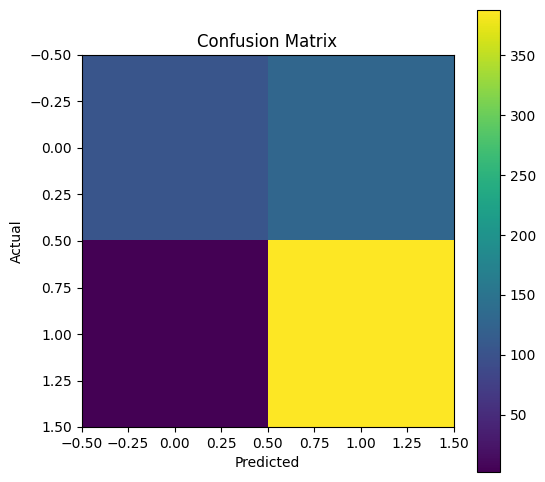

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "../results/figures/confusion_matrix.png"
)

plt.show()